# 1. Perkenalan Dataset

Dataset yang digunakan pada eksperimen ini adalah Titanic Dataset yang diperoleh dari public repository.

# 2. Import Library

In [7]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import config

# 3. Memuat Dataset

In [8]:
def load_data(filepath: Path, fallback_url: str) -> pd.DataFrame:
    filepath.parent.mkdir(parents=True, exist_ok=True)

    if filepath.exists():
        print('[INFO] Dataset ditemukan di lokal.')
        return pd.read_csv(filepath)

    print('[INFO] Dataset tidak ditemukan. Mengunduh dataset...')

    df = pd.read_csv(fallback_url)
    df.to_csv(filepath, index=False)

    print(f'[INFO] Dataset berhasil disimpan ke: {filepath}')

    return df


df = load_data(
    filepath=config.DATASET_DIR / 'titanic_raw.csv',
    fallback_url=config.DATASET_URL
)

df.head()

[INFO] Dataset ditemukan di lokal.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Exploratory Data Analysis (EDA)

In [9]:
print('--- Informasi Dataset ---')
df.info()

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
print('--- Statistik Deskriptif Dataset ---')
df.describe()

--- Statistik Deskriptif Dataset ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print('--- Missing Values ---')
df.isnull().sum()

--- Missing Values ---


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

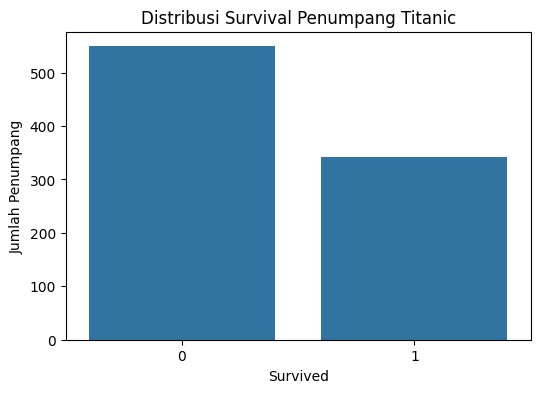

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived')

plt.title('Distribusi Survival Penumpang Titanic')
plt.xlabel('Survived')
plt.ylabel('Jumlah Penumpang')

plt.show()

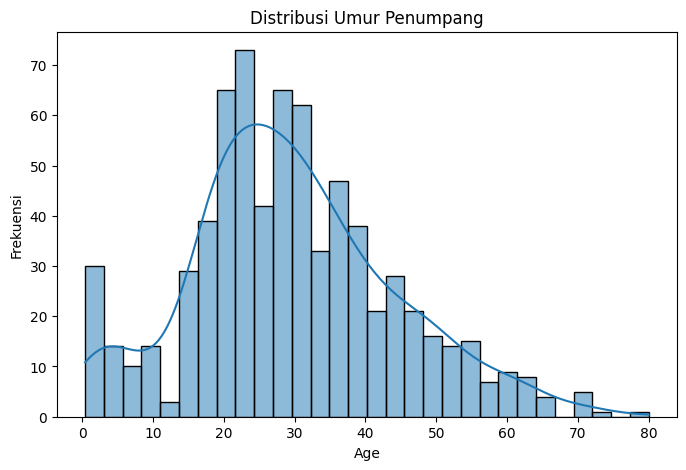

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Distribusi Umur Penumpang')
plt.xlabel('Age')
plt.ylabel('Frekuensi')

plt.show()

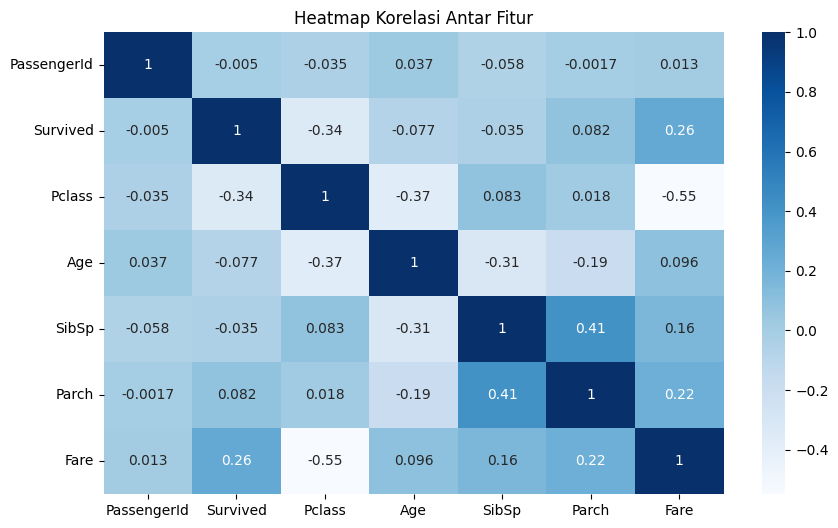

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')

plt.title('Heatmap Korelasi Antar Fitur')

plt.show()

# 5. Preprocessing Data

In [15]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()

    df_clean = df_clean.drop(
        columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
    )

    df_clean['Age'] = df_clean['Age'].fillna(
        df_clean['Age'].median()
    )

    df_clean['Embarked'] = df_clean['Embarked'].fillna(
        df_clean['Embarked'].mode()[0]
    )

    df_clean = pd.get_dummies(
        df_clean,
        columns=['Sex', 'Embarked'],
        drop_first=True
    )

    return df_clean


df_processed = preprocess_data(df)

df_processed.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# 6. Menyimpan Dataset

In [ ]:
def save_data(df: pd.DataFrame, filepath: Path) -> None:
    filepath.parent.mkdir(parents=True, exist_ok=True)

    df.to_csv(filepath, index=False)

    print(f'[INFO] Dataset berhasil disimpan ke: {filepath}')


save_data(
    df=df_processed,
    filepath=config.DATASET_DIR / 'clean.csv'
)

print('[INFO] Data pipeline selesai.')

[INFO] Dataset berhasil disimpan ke: D:\Project\titanic-system\dataset\titanic_processed.csv
[INFO] Data pipeline selesai.
